In [171]:
import polars as pl
from matplotlib import pyplot as plt
import pandas as pd

min_year, max_year = -100, 1000

df = (
    pl
    .read_csv(
        "../cross-verified-database.csv.gz",
        encoding="utf8-lossy",
        columns=[
            "birth",
            "death",
            "gender",
            "un_region",
            "un_subregion",
            "level1_main_occ",
            "level2_main_occ",
            "name",
        ],
    )
    .filter((pl.col("birth").is_not_null()) & pl.col("death").is_not_null())
    .filter([pl.col("birth") < max_year, pl.col("birth") >= min_year])
)

print(df.shape), df
df.head()

(7068, 8)


birth,death,gender,level1_main_occ,name,un_subregion,level2_main_occ,un_region
i64,i64,str,str,str,str,str,str
326,360,"""Female""","""Leadership""","""Helena_(wife_of_Julian)""","""Southern Europe""","""Nobility""","""Europe"""
385,433,"""Male""","""Leadership""","""Dharmakṣema""","""Eastern Asia""","""Religious""","""Asia"""
554,639,"""Male""","""Discovery/Science""","""Fu_Yi""","""Eastern Asia""","""Academia""","""Asia"""
748,835,"""Male""","""Missing""","""Nanquan_Puyuan""","""Eastern Asia""","""Missing""","""Asia"""
925,992,"""Male""","""Leadership""","""Herbert_of_Wetterau""","""Western Europe""","""Nobility""","""Europe"""


In [172]:
df["level1_main_occ"].value_counts(normalize=True).sort("proportion", descending=True)

level1_main_occ,proportion
str,f64
"""Leadership""",0.74717
"""Culture""",0.090266
"""Discovery/Science""",0.079796
"""Other""",0.069185
"""Missing""",0.011036
"""Sports/Games""",0.002547


# Data Creation


In [173]:
# Calendar-year x age hazard table.
# No year 0: 1 BC -> AD 1. birth == 0 is a missing code; lifespans outside [1, 110] are data errors.
cc_df = df.with_columns(
    (
        pl.col("death")
        - pl.col("birth")
        - ((pl.col("birth") < 0) & (pl.col("death") > 0)).cast(pl.Int64)
    ).alias("lifespan")
).filter(pl.col("birth") != 0, pl.col("lifespan").is_between(1, 110))

# One row per person per year of life.
person_years = (
    cc_df
    .select("birth", "lifespan")
    .with_columns(pl.int_ranges(0, pl.col("lifespan") + 1).alias("age"))
    .explode("age", empty_as_null=True)
    .with_columns(
        (
            pl.col("birth")
            + pl.col("age")
            + ((pl.col("birth") < 0) & (pl.col("birth") + pl.col("age") >= 0)).cast(
                pl.Int64
            )
        ).alias("year"),
        (pl.col("age") == pl.col("lifespan")).alias("died"),
    )
)

# Risk set = everyone alive at that age in that year, including those who die in it.
lexis = (
    person_years
    .group_by("year", "age")
    .agg(pl.len().alias("at_risk"), pl.col("died").sum().alias("deaths"))
    .with_columns((pl.col("deaths") / pl.col("at_risk")).alias("hazard"))
    .sort("age", "year")
)

# Rows = calendar year, columns = age. null = nobody at risk; 0 = at risk, no deaths.
hazard_mat = lexis.pivot(on="age", index="year", values="hazard").sort("year")
hazard_mat

year,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-100,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
-99,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
-98,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
-97,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
-96,null,0.0,0.0,0.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1090,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1091,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,0.5,null,null,null,null,null,null,null,null,null,null,null,null,null
1092,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,null,null,0.0,null,null,null,null,null,null,null,null,null,null,null,null


# Poisson Model: spline in year, linear in age


In [174]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# log E[deaths] = log(at_risk) + s(year) + b*age, s = natural cubic spline.
# constraints="center" keeps the spline basis from being collinear with the intercept.
# scale="X2" inflates SEs for the mild overdispersion (Pearson chi2/df ~ 1.15).
lexis_pd = pd.DataFrame(lexis.to_dict(as_series=False))

spline_fit = smf.glm(
    "deaths ~ cr(year, df=10, constraints='center') + age",
    data=lexis_pd,
    family=sm.families.Poisson(),
    offset=np.log(lexis_pd["at_risk"]),
).fit(scale="X2")

spline_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                78619
Model:                            GLM   Df Residuals:                    78607
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.1528
Method:                          IRLS   Log-Likelihood:                -18475.
Date:                Sat, 03 Oct 2026   Deviance:                       29673.
Time:                        15:01:02   Pearson chi2:                 9.06e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.07488
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -5.8193      0.033   -173.805      0.000      -5.885      -5.754
cr(year, df=10, constraints='center')[0]     0.2997      0.094      3.175      0.001       0.115       0.485
cr(year, df=10, constraints='center')[1]    -0.1222      0.072     -1.691      0.091      -0.264       0.019
cr(year, df=10, constraints='center')[2]     0.2519      0.082      3.062      0.002       0.091       0.413
cr(year, df=10, constraints='center')[3]    -0.1502      0.076     -1.981      0.048      -0.299      -0.002
cr(year, df=10, constraints='center')[4]    -0.1552      0.080     -1.932      0.053      -0.313       0.002
cr(year, df=10, constraints='center')[5]    -0.1994      0.083     -2.390      0.017      -0.363      -0.036
cr(year, df=10, constraints='center')[6]    -0.1200      0.082     -1.469      0.142      -0.280       0.040
cr(year, df=10, constraints='center')[7]    -0.0743      0.080     -0.927      0.354      -0.231       0.083
cr(year, df=10, constraints='center')[8]     0.0052      0.078      0.067      0.947      -0.148       0.158
cr(year, df=10, constraints='center')[9]     0.1485      0.102      1.461      0.144      -0.051       0.348
age                                          0.0436      0.001     75.570      0.000       0.042       0.045
============================================================================================================
"""

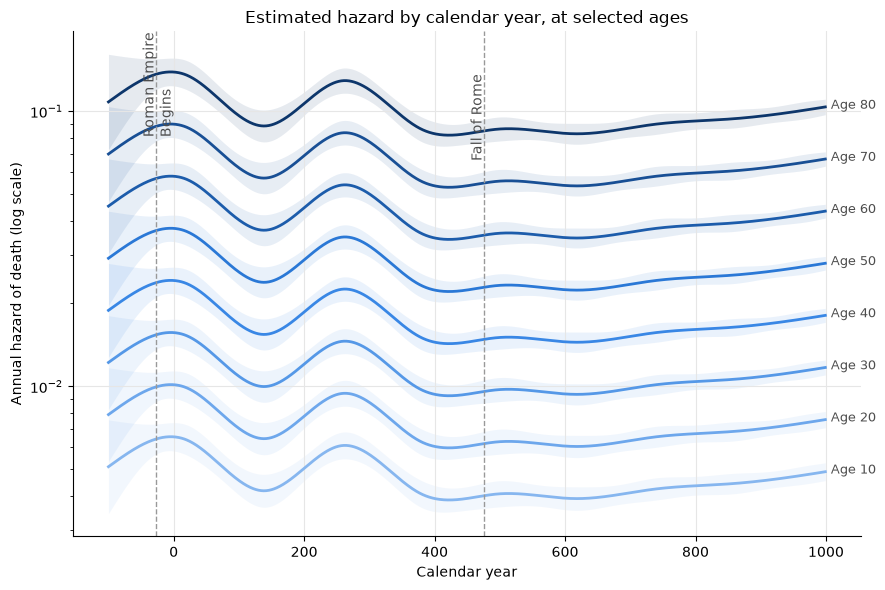

In [175]:
# Fitted annual hazard vs. calendar year at sample ages, with 95% CIs.
# Births stop at 999, so years past 1000 have only older people at risk; plot to 1000.
years = np.arange(lexis_pd["year"].min(), max_year)
# Ages 10-80, light -> dark blue ramp.
sample_ages = dict(
    zip(
        range(10, 81, 10),
        [
            "#86b6ef",
            "#6da7ec",
            "#5598e7",
            "#3987e5",
            "#2a78d6",
            "#1c5cab",
            "#184f95",
            "#0d366b",
        ],
    )
)

fig, ax = plt.subplots(figsize=(9, 6))
for age, color in sample_ages.items():
    grid = pd.DataFrame({"year": years, "age": age})
    pred = spline_fit.get_prediction(grid, offset=np.zeros(len(grid))).summary_frame()
    ax.fill_between(
        years,
        pred["mean_ci_lower"],
        pred["mean_ci_upper"],
        color=color,
        alpha=0.1,
        lw=0,
    )
    ax.plot(years, pred["mean"], color=color, lw=2, label=f"Age {age}")
    ax.annotate(
        f"Age {age}",
        (years[-1], pred["mean"].iloc[-1]),
        xytext=(4, 1),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color="0.3",
    )

ax.axvline(476, color="0.6", lw=1, ls="--")
ax.text(
    455,
    0.75,
    "Fall of Rome",
    transform=ax.get_xaxis_transform(),
    fontsize=10,
    color="0.3",
    rotation=90,
)
ax.axvline(-27, color="0.6", lw=1, ls="--")
ax.text(
    -50,
    0.80,
    "Roman Empire\nBegins",
    transform=ax.get_xaxis_transform(),
    fontsize=10,
    color="0.3",
    rotation=90,
)
ax.set_yscale("log")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Annual hazard of death (log scale)")
ax.set_title("Estimated hazard by calendar year, at selected ages")
ax.grid(True, which="major", color="0.9", lw=0.8)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(frameon=False, loc="upper right")
fig.tight_layout()

# Nested Poisson models: year, then region, then occupation, then region-specific year curves

Nested models on the same sample (Europe + Asia, occupation known), each with the
`log(at_risk)` offset:

| model | linear predictor                                           |
| ----- | ---------------------------------------------------------- |
| M1    | s(year) + age                                              |
| M2    | s(year) + age + region                                     |
| M3    | s(year) + age + region + sub-occupation                    |
| M4    | s(year) + age + region + sub-occupation + s(year) : region |

Age and sub-occupation act proportionally (constant hazard ratios over time); only the shape of
the year curve is allowed to differ, and only between regions (M4). The year spline is kept in
every model; its df is chosen by blocked CV on M1 and held fixed for M2–M4 so the models stay
nested.

**Regions.** Region comes from each person's modern country of attachment (UN regions), not the
polity they lived in. UN "Asia" therefore includes Anatolia, the Levant, Mesopotamia, Iran and
the Caucasus (much of the Eastern Roman world and its neighbours) alongside China, Japan, Korea
and India. Asia is split into **Western Asia** and **East & South Asia** (no political link to
Rome); Europe includes a separate "Roman Empire" attachment category.

**Sub-occupation, not occupation.** Level-1 "Leadership" mixes nobility, clergy, politicians and
soldiers. Religious leaders have roughly half the hazard of secular ones, and their share of
recorded leaders rises from ~3% (births before 0 CE) to ~43% (200–800 CE) and falls back to 25%
(800–1000). Adjusting only for level-1 occupation lets that compositional shift masquerade as a
calendar-time effect, so the models use level-2 occupation (Nobility is the reference).

**Delayed entry at age 25.** People enter the database by becoming notable, so they cannot have
died before reaching the age at which they became notable. Person-years before that age carry no
risk of an observed death (immortal time), and they are concentrated at young ages. Each person
therefore enters the risk set at `entry_age = 25`: earlier person-years are dropped, and people
who died before 25 drop out entirely.


In [176]:
# Europe + Asia only, complete case on occupation. Occupation is the level-2 (sub-)occupation,
# because level 1 lumps groups with very different hazards (e.g. Leadership = nobility, clergy,
# politicians, soldiers). Small level-2 categories are folded into their nearest neighbour.
occ_groups = {
    "Politics": "Politics/Administration",
    "Administration/Law": "Politics/Administration",
    "Corporate/Executive/Business (large)": "Politics/Administration",
    "Culture-core": "Culture",
    "Culture-periphery": "Culture",
    "Academia": "Academia/Science",
    "Explorer/Inventor/Developer": "Academia/Science",
    "Worker/Business (small)": "Other",
    "Sports/Games": "Other",
}
# Regions come from each person's modern country of attachment (UN regions), so "Asia" mixes the
# Eastern Roman / Near Eastern world (Anatolia, Levant, Mesopotamia, Iran, Caucasus) with East and
# South Asia. Split it so East & South Asia, with no political link to Rome, is its own region.
asia_groups = {
    "Western Asia (Middle East Caucasus)": "Western Asia",
    "Central Asia": "Western Asia",
    "Eastern Asia": "East & South Asia",
    "South Asia incl. Indian Peninsula": "East & South Asia",
    "SouthEast Asia": "East & South Asia",
}
regions = ["Europe", "Western Asia", "East & South Asia"]
ea_df = cc_df.filter(
    pl.col("un_region").is_in(["Europe", "Asia"]),
    pl.col("level1_main_occ") != "Missing",
).with_columns(
    pl.col("level2_main_occ").replace(occ_groups).alias("occ"),
    pl
    .when(pl.col("un_region") == "Europe")
    .then(pl.lit("Europe"))
    .otherwise(pl.col("un_subregion").replace(asia_groups))
    .alias("region"),
)

# Same year x age risk sets as `lexis`, split by occupation and region.
lexis_ea = (
    ea_df
    .select("birth", "lifespan", "occ", "region")
    .with_columns(pl.int_ranges(0, pl.col("lifespan") + 1).alias("age"))
    .explode("age", empty_as_null=True)
    .with_columns(
        (
            pl.col("birth")
            + pl.col("age")
            + ((pl.col("birth") < 0) & (pl.col("birth") + pl.col("age") >= 0)).cast(
                pl.Int64
            )
        ).alias("year"),
        (pl.col("age") == pl.col("lifespan")).alias("died"),
    )
    .group_by("year", "age", "occ", "region")
    .agg(pl.len().alias("at_risk"), pl.col("died").sum().alias("deaths"))
)
d = pd.DataFrame(lexis_ea.to_dict(as_series=False))
print(ea_df.height, "people,", len(d), "cells")

# Occupation mix by region: the potential confounding path.
(
    ea_df
    .group_by("region", "occ")
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("region")).round(3).alias("share")
    )
    .pivot(on="region", index="occ", values="share")
)

5902 people, 220742 cells


occ,Europe,East & South Asia,Western Asia
str,f64,f64,f64
"""Academia/Science""",0.056,0.073,0.191
"""Politics/Administration""",0.101,0.161,0.064
"""Culture""",0.05,0.193,0.079
"""Family""",0.06,0.045,0.059
"""Religious""",0.312,0.057,0.348
"""Other""",0.007,0.013,0.004
"""Military""",0.026,0.105,0.05
"""Nobility""",0.389,0.353,0.205


## The year spline: basis, knots, and `constraints='center'`

**Basis.** `cr()` is patsy's natural cubic regression spline (the same basis as mgcv's `"cr"`).
It is cubic between knots and linear beyond the boundary knots. It spans the same space as a
natural cubic B-spline basis with the same knots; only the parameterization differs (each `cr`
coefficient is roughly the value of the curve at one knot, rather than a B-spline weight).

**Knots.** With `df = k`, `year_spline(k)` places `k - 1` interior knots _evenly spaced in calendar
time_ between the first and last year in the data, plus boundary knots at those two years
(here -100 and 1094):

| df  | interior knots                             | spacing  |
| --- | ------------------------------------------ | -------- |
| 2   | 497                                        | ~600 yrs |
| 5   | 139, 378, 616, 855                         | ~240 yrs |
| 10  | 19, 139, 258, 378, 497, 616, 736, 855, 975 | ~120 yrs |

Quantile knots (patsy's default, e.g. `bs(year, df=k)`) would put the knots at quantiles of the
_rows_, which pile up where the data are dense (later centuries) and leave the Roman period with
few knots.

**`constraints='center'`.** An unconstrained `cr` basis has one column per knot (k + 1 columns), and
its columns sum to exactly 1 in every row, so they are perfectly collinear with the intercept.
`constraints='center'` removes that redundancy: it reparameterizes the basis into k columns
under the constraint that the fitted spline sums to zero over the rows of the data. The spline is
then a deviation from the intercept, the coefficients are identified, and `df` counts the
columns actually estimated. Predictions are unaffected; only the split between intercept and
spline changes. (With `bs()` the same job is done by dropping one basis column, `include_intercept=False`.)


In [177]:
from scipy import stats

entry_age = 25  # set to 0 to count people at risk from birth
dm = d[d["age"] >= entry_age]
print(
    ea_df.filter(pl.col("lifespan") >= entry_age).height,
    "people,",
    int(dm["deaths"].sum()),
    "deaths,",
    len(dm),
    "cells",
)

year_lo, year_hi = dm["year"].min(), dm["year"].max()


def year_spline(df):
    """Natural cubic spline in year: df columns, interior knots evenly spaced in time."""
    knots = np.linspace(year_lo, year_hi, df + 1)[1:-1].round(1).tolist()
    return (
        f"cr(year, knots={knots}, lower_bound={year_lo}, upper_bound={year_hi},"
        " constraints='center')"
    )


# Nested models: each adds one term to the previous one. "{s}" stands for the year spline.
terms = {
    "M1": "",
    "M2": " + C(region, Treatment('Europe'))",
    "M3": " + C(region, Treatment('Europe')) + C(occ, Treatment('Nobility'))",
}
terms["M4"] = (
    terms["M3"] + " + {s}:C(region, Treatment('Europe'))"
)  # year curve by region


def fit_model(name, df, data=dm, **fit_kwds):
    s = year_spline(df)
    return smf.glm(
        f"deaths ~ {s} + age" + terms[name].replace("{s}", s),
        data=data,
        family=sm.families.Poisson(),
        offset=np.log(data["at_risk"]),
    ).fit(**fit_kwds)


def poisson_deviance(y, mu):
    return 2 * np.sum(y * np.log(np.where(y > 0, y / mu, 1)) - (y - mu))


def cv_deviance(name, df, data=dm):
    """Blocked CV: 25-year blocks of calendar time dealt into 5 folds."""
    fold = ((data["year"] - year_lo) // 25) % 5
    total = 0.0
    for k in range(5):
        train, test = data[fold != k], data[fold == k]
        mu = fit_model(name, df, train).predict(test, offset=np.log(test["at_risk"]))
        total += poisson_deviance(test["deaths"].to_numpy(), mu.to_numpy())
    return total


# Step 1: choose the year spline df on M1 (age + year only).
dfs = [2, 3, 4, 5, 8]
cv = pd.Series([cv_deviance("M1", k) for k in dfs], index=pd.Index(dfs, name="df"))
cv = cv - cv.min()  # deviance above the best df
best_df = int(cv.idxmin())
cv.round(1)

5258 people, 5258 deaths, 129169 cells


df
2     0.0
3     7.7
4    18.0
5    17.9
8    54.5
dtype: float64

In [178]:
# Step 2: add region, then occupation, then the year x age term, at the M1 df. LR test against
# the previous model (deviance difference ~ chi2 with df = added parameters) and blocked CV.
fits = {name: fit_model(name, best_df) for name in terms}
comparison = pd.DataFrame({
    "n_params": {n: int(f.df_model) + 1 for n, f in fits.items()},
    "deviance": {n: f.deviance for n, f in fits.items()},
    "pearson_scale": {n: f.pearson_chi2 / f.df_resid for n, f in fits.items()},
    "cv_deviance": {n: cv_deviance(n, best_df) for n in terms},
})
comparison["lr_chi2"] = -comparison["deviance"].diff()
comparison["lr_df"] = comparison["n_params"].diff()
comparison["lr_p"] = stats.chi2.sf(comparison["lr_chi2"], comparison["lr_df"])
comparison["cv_vs_best"] = comparison["cv_deviance"] - comparison["cv_deviance"].min()
comparison.drop(columns="cv_deviance").round(3).assign(
    lr_p=comparison["lr_p"].map("{:.2g}".format)
)

,n_params,deviance,pearson_scale,lr_chi2,lr_df,lr_p,cv_vs_best
M1,4,30381.157,0.987,NaN,NaN,nan,467.990
M2,6,30309.076,0.995,72.081,2.0,2.2e-16,407.344
M3,13,29879.459,0.951,429.616,7.0,1.1e-88,0.000
M4,17,29873.138,0.951,6.322,4.0,0.18,14.751


In [179]:
# Hazard ratios for the non-spline terms in each model (SEs scaled for overdispersion).
hr_rows = {}
for name in terms:
    f = fit_model(name, best_df, scale="X2")
    keep = ~f.params.index.str.startswith(("cr(", "Intercept"))
    ci = np.exp(f.conf_int()[keep])
    hr_rows[name] = pd.DataFrame({
        "hazard_ratio": np.exp(f.params[keep]),
        "ci_lower": ci[0],
        "ci_upper": ci[1],
    })
pd.concat(hr_rows, names=["model", "term"]).round(3)

hazard_ratio  \
model term                                                               
M1    age                                                        1.044   
M2    C(region, Treatment('Europe'))[T.East & South A...         1.030   
      C(region, Treatment('Europe'))[T.Western Asia]             0.748   
      age                                                        1.045   
M3    C(region, Treatment('Europe'))[T.East & South A...         0.929   
      C(region, Treatment('Europe'))[T.Western Asia]             0.823   
      C(occ, Treatment('Nobility'))[T.Academia/Science]          0.519   
      C(occ, Treatment('Nobility'))[T.Culture]                   0.648   
      C(occ, Treatment('Nobility'))[T.Family]                    1.014   
      C(occ, Treatment('Nobility'))[T.Military]                  0.956   
      C(occ, Treatment('Nobility'))[T.Other]                     0.632   
      C(occ, Treatment('Nobility'))[T.Politics/Admini...         0.816   
      C(occ, Treatment('Nobility'))[T.Religious]                 0.501   
      age                                                        1.048   
M4    C(region, Treatment('Europe'))[T.East & South A...         0.928   
      C(region, Treatment('Europe'))[T.Western Asia]             0.807   
      C(occ, Treatment('Nobility'))[T.Academia/Science]          0.508   
      C(occ, Treatment('Nobility'))[T.Culture]                   0.638   
      C(occ, Treatment('Nobility'))[T.Family]                    1.006   
      C(occ, Treatment('Nobility'))[T.Military]                  0.958   
      C(occ, Treatment('Nobility'))[T.Other]                     0.623   
      C(occ, Treatment('Nobility'))[T.Politics/Admini...         0.803   
      C(occ, Treatment('Nobility'))[T.Religious]                 0.500   
      age                                                        1.048   

                                                          ci_lower  ci_upper  
model term                                                                    
M1    age                                                    1.043     1.046  
M2    C(region, Treatment('Europe'))[T.East & South A...     0.968     1.096  
      C(region, Treatment('Europe'))[T.Western Asia]         0.693     0.807  
      age                                                    1.043     1.047  
M3    C(region, Treatment('Europe'))[T.East & South A...     0.869     0.993  
      C(region, Treatment('Europe'))[T.Western Asia]         0.762     0.888  
      C(occ, Treatment('Nobility'))[T.Academia/Science]      0.469     0.574  
      C(occ, Treatment('Nobility'))[T.Culture]               0.588     0.713  
      C(occ, Treatment('Nobility'))[T.Family]                0.895     1.150  
      C(occ, Treatment('Nobility'))[T.Military]              0.841     1.086  
      C(occ, Treatment('Nobility'))[T.Other]                 0.467     0.855  
      C(occ, Treatment('Nobility'))[T.Politics/Admini...     0.741     0.900  
      C(occ, Treatment('Nobility'))[T.Religious]             0.465     0.540  
      age                                                    1.046     1.049  
M4    C(region, Treatment('Europe'))[T.East & South A...     0.868     0.993  
      C(region, Treatment('Europe'))[T.Western Asia]         0.744     0.875  
      C(occ, Treatment('Nobility'))[T.Academia/Science]      0.458     0.563  
      C(occ, Treatment('Nobility'))[T.Culture]               0.579     0.703  
      C(occ, Treatment('Nobility'))[T.Family]                0.887     1.141  
      C(occ, Treatment('Nobility'))[T.Military]              0.843     1.089  
      C(occ, Treatment('Nobility'))[T.Other]                 0.460     0.843  
      C(occ, Treatment('Nobility'))[T.Politics/Admini...     0.727     0.886  
      C(occ, Treatment('Nobility'))[T.Religious]             0.464     0.539  
      age                                                    1.046     1.050

In [180]:
# Write-up tables: model comparison and hazard ratios (95% CI) by model, printed as Markdown
# for Google Docs (Edit > Paste from Markdown, after Tools > Preferences > Enable Markdown).
from IPython.display import display


def to_markdown(table):
    header = [table.index.name or ""] + list(table.columns)
    lines = ["| " + " | ".join(header) + " |", "|" + " --- |" * len(header)]
    lines += [
        "| " + " | ".join([str(i), *map(str, row)]) + " |"
        for i, row in table.iterrows()
    ]
    return "\n".join(lines)


added = {
    "M1": "year spline + age",
    "M2": "+ region",
    "M3": "+ sub-occupation",
    "M4": "+ year spline × region",
}
comparison_table = pd.DataFrame(
    {
        "Terms": pd.Series(added),
        "Parameters": comparison["n_params"],
        "Deviance": comparison["deviance"].map("{:,.1f}".format),
        "LR χ² (df)": [
            "—" if np.isnan(c) else f"{c:.1f} ({int(k)})"
            for c, k in zip(comparison["lr_chi2"], comparison["lr_df"])
        ],
        "p": [
            "—" if np.isnan(p) else ("<0.001" if p < 0.001 else f"{p:.3f}")
            for p in comparison["lr_p"]
        ],
        "Δ CV deviance": comparison["cv_vs_best"].map("{:.1f}".format),
    },
    index=comparison.index,
)
comparison_table.index.name = "Model"

occ_order = [
    "Religious",
    "Politics/Administration",
    "Military",
    "Family",
    "Academia/Science",
    "Culture",
    "Other",
]
labels = {
    "age": "Age (per 10 years)",
    **{
        f"C(region, Treatment('Europe'))[T.{r}]": f"{r} (vs. Europe)"
        for r in regions[1:]
    },
    **{
        f"C(occ, Treatment('Nobility'))[T.{o}]": f"{o} (vs. Nobility)"
        for o in occ_order
    },
}


def hr_ci(fit, term):
    per = 10 if term == "age" else 1
    b, (lo, hi) = fit.params[term] * per, fit.conf_int().loc[term] * per
    return f"{np.exp(b):.2f} ({np.exp(lo):.2f}–{np.exp(hi):.2f})"


scaled_fits = {name: fit_model(name, best_df, scale="X2") for name in terms}
hr_table = pd.DataFrame(
    {
        name: [hr_ci(f, t) if t in f.params else "—" for t in labels]
        for name, f in scaled_fits.items()
    },
    index=pd.Index(labels.values(), name="Hazard ratio (95% CI)"),
)

display(comparison_table, hr_table)
print(to_markdown(comparison_table))
print()
print(to_markdown(hr_table))

,Terms,Parameters,Deviance,LR χ² (df),p,Δ CV deviance
Model,,,,,,
M1,year spline + age,4,"30,381.2",—,—,468.0
M2,+ region,6,"30,309.1",72.1 (2),<0.001,407.3
M3,+ sub-occupation,13,"29,879.5",429.6 (7),<0.001,0.0
M4,+ year spline × region,17,"29,873.1",6.3 (4),0.176,14.8


,M1,M2,M3,M4
Hazard ratio (95% CI),,,,
Age (per 10 years),1.54 (1.52–1.56),1.55 (1.53–1.58),1.60 (1.57–1.62),1.60 (1.57–1.62)
Western Asia (vs. Europe),—,0.75 (0.69–0.81),0.82 (0.76–0.89),0.81 (0.74–0.88)
East & South Asia (vs. Europe),—,1.03 (0.97–1.10),0.93 (0.87–0.99),0.93 (0.87–0.99)
Religious (vs. Nobility),—,—,0.50 (0.47–0.54),0.50 (0.46–0.54)
Politics/Administration (vs. Nobility),—,—,0.82 (0.74–0.90),0.80 (0.73–0.89)
Military (vs. Nobility),—,—,0.96 (0.84–1.09),0.96 (0.84–1.09)
Family (vs. Nobility),—,—,1.01 (0.89–1.15),1.01 (0.89–1.14)
Academia/Science (vs. Nobility),—,—,0.52 (0.47–0.57),0.51 (0.46–0.56)
Culture (vs. Nobility),—,—,0.65 (0.59–0.71),0.64 (0.58–0.70)


| Model | Terms | Parameters | Deviance | LR χ² (df) | p | Δ CV deviance |
| --- | --- | --- | --- | --- | --- | --- |
| M1 | year spline + age | 4 | 30,381.2 | — | — | 468.0 |
| M2 | + region | 6 | 30,309.1 | 72.1 (2) | <0.001 | 407.3 |
| M3 | + sub-occupation | 13 | 29,879.5 | 429.6 (7) | <0.001 | 0.0 |
| M4 | + year spline × region | 17 | 29,873.1 | 6.3 (4) | 0.176 | 14.8 |

| Hazard ratio (95% CI) | M1 | M2 | M3 | M4 |
| --- | --- | --- | --- | --- |
| Age (per 10 years) | 1.54 (1.52–1.56) | 1.55 (1.53–1.58) | 1.60 (1.57–1.62) | 1.60 (1.57–1.62) |
| Western Asia (vs. Europe) | — | 0.75 (0.69–0.81) | 0.82 (0.76–0.89) | 0.81 (0.74–0.88) |
| East & South Asia (vs. Europe) | — | 1.03 (0.97–1.10) | 0.93 (0.87–0.99) | 0.93 (0.87–0.99) |
| Religious (vs. Nobility) | — | — | 0.50 (0.47–0.54) | 0.50 (0.46–0.54) |
| Politics/Administration (vs. Nobility) | — | — | 0.82 (0.74–0.90) | 0.80 (0.73–0.89) |
| Military (vs. Nobility) | — | — | 0.96 (0.84–1.09) | 0.96 (0.84–1.09) |
| Family (vs. Nob

In [ ]:
# Did the post-476 rise extend beyond Europe? Region-specific change in hazard between two years
# from M4 (age and occupation are proportional, so these ratios hold at every age and
# occupation), and each region's change relative to Europe's. M3 (common curve) for reference.
from statsmodels.formula._manager import FormulaManager


def design(fit, frame):
    spec = fit.model.data.model_spec
    return np.asarray(
        FormulaManager().get_matrices(spec, frame, pandas=False, prediction=True)
    )


def ratio_ci(fit, x_num, x_den):
    """exp of a linear contrast (x_num - x_den) @ beta, with 95% CI."""
    diff = x_num - x_den
    est = diff @ fit.params.to_numpy()
    se = np.sqrt(diff @ fit.cov_params().to_numpy() @ diff)
    return f"{np.exp(est):.2f} ({np.exp(est - 1.96 * se):.2f}–{np.exp(est + 1.96 * se):.2f})"


def row(fit, region, year):
    frame = pd.DataFrame({
        "year": [year],
        "age": 50,
        "occ": "Nobility",
        "region": region,
    })
    return design(fit, frame)[0]


periods = {"fall (−75 → 476)": (-75, 476), "rise (476 → 1000)": (476, 1000)}
change_rows = {}
for name in ["M3", "M4"]:
    f = scaled_fits[name]
    for label, (y0, y1) in periods.items():
        change = {r: row(f, r, y1) - row(f, r, y0) for r in regions}
        zero = np.zeros_like(change["Europe"])
        change_rows[(name, label)] = {
            **{r: ratio_ci(f, change[r], zero) for r in regions},
            **{
                f"{r} / Europe": ratio_ci(f, change[r], change["Europe"])
                for r in regions[1:]
            },
        }
region_change = pd.DataFrame(change_rows).T
region_change.index.names = ["Model", "Hazard ratio (95% CI)"]
display(region_change)

region_change_md = region_change.copy()
region_change_md.index = [f"{m}: {period}" for m, period in region_change.index]
region_change_md.index.name = "Hazard ratio (95% CI)"
print(to_markdown(region_change_md))


Europe      Western Asia  \
Model Hazard ratio (95% CI)                                       
M3    fall (−75 → 476)       0.80 (0.70–0.91)  0.80 (0.70–0.91)   
      rise (476 → 1000)      1.16 (1.08–1.25)  1.16 (1.08–1.25)   
M4    fall (−75 → 476)       0.76 (0.64–0.89)  0.88 (0.59–1.32)   
      rise (476 → 1000)      1.13 (1.03–1.25)  1.36 (1.14–1.61)   

                            East & South Asia Western Asia / Europe  \
Model Hazard ratio (95% CI)                                           
M3    fall (−75 → 476)       0.80 (0.70–0.91)      1.00 (1.00–1.00)   
      rise (476 → 1000)      1.16 (1.08–1.25)      1.00 (1.00–1.00)   
M4    fall (−75 → 476)       0.94 (0.71–1.24)      1.16 (0.75–1.79)   
      rise (476 → 1000)      1.11 (0.96–1.28)      1.20 (0.98–1.45)   

                            East & South Asia / Europe  
Model Hazard ratio (95% CI)                             
M3    fall (−75 → 476)                1.00 (1.00–1.00)  
      rise (476 → 1000)               1.00 (1.00–1.00)  
M4    fall (−75 → 476)                1.24 (0.90–1.70)  
      rise (476 → 1000)               0.98 (0.82–1.17)

| Hazard ratio (95% CI) | Europe | Western Asia | East & South Asia | Western Asia / Europe | East & South Asia / Europe |
| --- | --- | --- | --- | --- | --- |
| M3: fall (−75 → 476) | 0.80 (0.70–0.91) | 0.80 (0.70–0.91) | 0.80 (0.70–0.91) | 1.00 (1.00–1.00) | 1.00 (1.00–1.00) |
| M3: rise (476 → 1000) | 1.16 (1.08–1.25) | 1.16 (1.08–1.25) | 1.16 (1.08–1.25) | 1.00 (1.00–1.00) | 1.00 (1.00–1.00) |
| M4: fall (−75 → 476) | 0.76 (0.64–0.89) | 0.88 (0.59–1.32) | 0.94 (0.71–1.24) | 1.16 (0.75–1.79) | 1.24 (0.90–1.70) |
| M4: rise (476 → 1000) | 1.13 (1.03–1.25) | 1.36 (1.14–1.61) | 1.11 (0.96–1.28) | 1.20 (0.98–1.45) | 0.98 (0.82–1.17) |


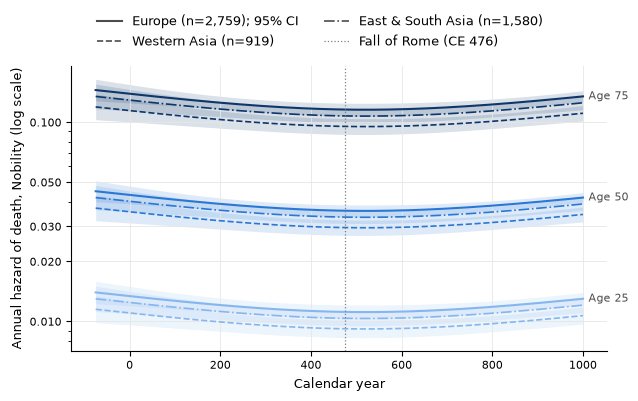

In [185]:
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, NullFormatter, ScalarFormatter

# Total hazard by calendar year from M4 at several ages on one log axis, one line style per
# region (Europe with 95% CI). Age and sub-occupation are proportional, so other occupations
# have the same curves shifted by their hazard ratio (table above).
# Drawn at the width it will have in the Google Doc (6.5" = letter page minus 1" margins), so
# inserting the PNG at that width keeps the fonts at their real point sizes.
plot_model = "M3"
plot_occ = "Nobility"
page_width = 6.5  # inches
font = {"title": 10, "label": 9, "tick": 8, "annot": 8, "legend": 9}
region_styles = {"Europe": "-", "Western Asia": "--", "East & South Asia": "-."}

fit = fit_model(plot_model, best_df, scale="X2")
years = np.arange(year_lo, max_year + 1)
ages = {25: "#86b6ef", 50: "#2a78d6", 75: "#0d366b"}
n_people = (
    ea_df
    .filter(pl.col("lifespan") >= entry_age)
    .group_by("region")
    .len()
    .rows_by_key("region", unique=True)
)

fig, ax = plt.subplots(figsize=(page_width, page_width * 0.62))
for age, color in ages.items():
    for region, ls in region_styles.items():
        grid = pd.DataFrame({
            "year": years,
            "age": age,
            "occ": plot_occ,
            "region": region,
        })
        pred = fit.get_prediction(grid, offset=np.zeros(len(grid))).summary_frame()
        ax.fill_between(
            years,
            pred["mean_ci_lower"],
            pred["mean_ci_upper"],
            color=color,
            alpha=0.15,
            lw=0,
        )
        if region == "Europe":
            ax.annotate(
                f"Age {age}",
                (years[-1], pred["mean"].iloc[-1]),
                xytext=(4, 0),
                textcoords="offset points",
                va="center",
                fontsize=font["annot"],
                color="0.3",
            )
        ax.plot(
            years,
            pred["mean"],
            color=color,
            lw=1.5 if region == "Europe" else 1.2,
            ls=ls,
        )

ax.axvline(476, color="0.5", lw=0.9, ls=":")
ax.set_xlabel("Calendar year", fontsize=font["label"])
ax.set_ylabel(f"Annual hazard of death, {plot_occ} (log scale)", fontsize=font["label"])
ax.tick_params(labelsize=font["tick"])
ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 3, 5)))
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="major", color="0.9", lw=0.6)
ax.spines[["top", "right"]].set_visible(False)

fig.legend(
    handles=[
        *[
            Line2D(
                [],
                [],
                color="0.3",
                lw=1.5 if r == "Europe" else 1.2,
                ls=ls,
                label=f"{r} (n={n_people[r][0]:,})"
                + ("; 95% CI" if r == "Europe" else ""),
            )
            for r, ls in region_styles.items()
        ],
        Line2D([], [], color="0.5", lw=0.9, ls=":", label="Fall of Rome (CE 476)"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncols=2,
    frameon=False,
    fontsize=font["legend"],
)
fig.tight_layout(rect=(0, 0, 1, 0.88))

# Insert in Docs at exactly page_width inches wide (Image options > Size).
fig.savefig("hazard_by_region.png", dpi=300)
